# Analyse et Modélisation des Trajets des Taxis Jaunes de New York

## Étape 1 – Exploration et Nettoyage des données (EDA)
Cette première étape constitue le fondement de tout le projet car la qualité des modèles dépendra directement de la rigueur du nettoyage

### Chargement des données avec Pandas et examiner la structure (types, dimensions, premières lignes).


In [1]:
import pandas as pd

df = pd.read_csv("../data/yellowtripdata_100k.csv")

print(df.shape)   # examen des dimensions de notre fichier (nb lignes, nbcoolonnes)

print("============")  #pour que je sépare les visualisations lors des tests
print(df.dtypes)  # types de chaque colonne
print("============")
df.info()         # pour que je vois les informations liées à ce fichier 
print("============")
df.head()         # aperçu des 5 premières lignes 

(99999, 19)
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               99999 non-null  int64  
 1   tpep_pickup_datetime   99999 non-null  object 
 2   tpep_dropoff_datetime  99

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-02-25 17:24:20,2016-02-25 17:27:20,2,0.70,-73.947250,40.763771,1,N,-73.992012,40.735390,2,5.0,0.0,0.5,0.0,0.0,0.3,5.8
1,2,2016-02-25 23:10:50,2016-02-25 23:31:50,2,5.52,-73.983017,40.750992,1,N,-73.988586,40.758839,2,20.0,0.5,0.5,0.0,0.0,0.3,21.3
2,2,2016-02-01 00:00:01,2016-02-01 00:10:52,6,1.99,-73.992340,40.758202,1,N,-73.964355,40.757977,1,9.5,0.5,0.5,0.7,0.0,0.3,11.5
3,1,2016-02-01 00:00:04,2016-02-01 00:05:16,1,1.50,-73.981453,40.749722,1,N,-73.982323,40.763985,2,6.5,0.5,0.5,0.0,0.0,0.3,7.8
4,2,2016-02-01 00:00:05,2016-02-01 00:20:59,1,5.60,-74.000603,40.729755,1,N,-73.951324,40.669834,1,20.0,0.5,0.5,4.0,0.0,0.3,25.3


## Etape 2 : Identification et traitement des valeurs manquantes



In [2]:
df.isnull().mean() * 100 #ici on voit qu'on a 0% de valeurs nulles pour toutes les colonnes dans nos colonnes, donc on a pas de valeurs manquantes

VendorID                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
pickup_longitude         0.0
pickup_latitude          0.0
RatecodeID               0.0
store_and_fwd_flag       0.0
dropoff_longitude        0.0
dropoff_latitude         0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
dtype: float64


### Etape 3 : Détecter et supprimer les valeurs aberrantes : distances nulles ou extrêmes, durées négatives, montants incohérents, nombres de passagers à zéro

In [3]:
df.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.529905,1.683587,2.839713,-72.856061,40.132128,1.027530,-72.906726,40.160923,1.298203,12.503560,0.354822,0.498365,1.844006,0.226339,0.299721,15.726812
std,0.499107,1.310736,3.277738,9.033356,4.976344,0.589117,8.828147,4.863469,0.472885,11.440619,0.228196,0.031382,2.518413,2.030771,0.012183,13.457994
min,1.000000,0.000000,0.000000,-74.547432,0.000000,1.000000,-74.609085,0.000000,1.000000,-59.000000,-0.500000,-0.500000,0.000000,0.000000,-0.300000,-59.300000
25%,1.000000,1.000000,1.020000,-73.992424,40.733551,1.000000,-73.991989,40.731117,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.800000
50%,2.000000,1.000000,1.730000,-73.983017,40.750923,1.000000,-73.980881,40.751030,1.000000,9.500000,0.500000,0.500000,1.500000,0.000000,0.300000,12.250000
75%,2.000000,2.000000,3.200000,-73.969566,40.765331,1.000000,-73.963730,40.766548,2.000000,14.500000,0.500000,0.500000,2.460000,0.000000,0.300000,17.800000
max,2.000000,6.000000,71.700000,0.000000,41.480785,99.000000,0.000000,41.480759,4.000000,1442.000000,1.300000,0.500000,326.440000,509.540000,0.300000,1442.800000


## Nettoyage – Montants et distances extrêmes 

In [4]:
#Justification des seuils pris précédemment : 

print(df["fare_amount"].quantile([0.99, 0.999]))
print(df["trip_distance"].quantile([ 0.99, 0.999]))
print(df["total_amount"].quantile([ 0.99, 0.999]))

0.990    52.0
0.999    80.0
Name: fare_amount, dtype: float64
0.990    17.9502
0.999    23.2004
Name: trip_distance, dtype: float64
0.990     65.39060
0.999    101.30008
Name: total_amount, dtype: float64


In [5]:
# Filtres sur les montants

# On crée df_clean à partir de df en appliquant le premier filtre

df_clean = df[
    (df["trip_distance"] > 0) &   # ici j'ai supprimé les distances nulles
    (df["fare_amount"] > 0) &    # je suppose qu'aucune course n'est gratuite 
    (df["passenger_count"] > 0)  # je filtre ici sur le nombre null de passager, donc je suppose qu'une course doit au minimum avoir 1 passager 

]

df_clean = df_clean[df_clean["fare_amount"] < 100]      # tarif > 100 dollars : montant aberrant car trop cher    
df_clean = df_clean[df_clean["total_amount"] > 0]       # total nul ou négatif, c'est un montant impossible 
df_clean = df_clean[df_clean["total_amount"] < 120]     # cohérence avec fare_amount, montant jugé excessif

# Filtres sur la distance
df_clean = df_clean[df_clean["trip_distance"] < 30]    # > 30 miles c'est aberrant car le seuil de nos valeurs était à 23 miles


# Filtres sur les passagers dejà fait en haut 

# Filtre sur RatecodeID : valeurs valides entre 1 et 5
df_clean = df_clean[df_clean["RatecodeID"].isin([1, 2, 3, 4, 5])]

# Filtres GPS
df_clean = df_clean[
    (df_clean["pickup_latitude"].between(39, 42)) &
    (df_clean["pickup_longitude"].between(-75, -72)) &
    (df_clean["dropoff_latitude"].between(39, 42)) &
    (df_clean["dropoff_longitude"].between(-75, -72))
]
#ici je fais un nettroyage en éliminant les valeurs extremes : par exemple la latitude entre 39 et 42 et la longitude entre -75 et -72 pour le pichup du passager ainsi que son dropoff

df_clean.shape

(97923, 19)

## Nettoyage – Montants et distances extrêmes

D'après les résultats précédents on a : 

- **fare_amount** : le percentile est 80$. 

On supprime les valeurs au-dessus de 100$ (légèrement au-dessus) et les valeurs négatives ou nulles.

99% coûtent moins de 52$ donc normal

99.9% coûtent moins de 80 $ 

donc au delà des 80$ le cout de la course ne serait pas normal, et celà m'a permis d'affiner mes filtres donc j'ai choisi 100 comme filtre

- **trip_distance** : le percentile est 23 miles, ce qui est cohérent 
  par conséquent, j'ai décidé de fixex le seuil à 30 miles pour conserver 
  les trajets vers les aéroports tout en éliminant les valeurs impossibles.

- **total_amount** : le percentile est 101$. 

On fixe le seuil à 120$ pour tenir compte des pourboires par exemple

- **passenger_count** : le nombre de passagers minimal est à 1

- **RatecodeID** : comme on peut voir sur le fichier ses valeurs sont comprises entre 1 et 5 seulement donc par convention, on accepte aucune autre valeur 

- **pickup_latitude/longitude et dropoff_latitude/longitude** : j'ai supposé que la longitude est entre -75 et -72 et la latitude entre 39 et 42, ces filtres délimitent la zone géographique de New York City et sa région  :

-42° c'est la limite nord de NYC 

-40.7°  New York City  

-39° c'est la limite sud (environ Philadelphia)

-75° c'est la limite ouest (environ Philadelphia)

-74° New York City 

-72° c'est la limite est (eastern side)


## Installation des bibliothèques

On installe Seaborn, bibliothèque de visualisation statistique  basée sur Matplotlib, qui permet de créer des graphiques 
plus esthétiques et expressifs avec moins de code.

In [6]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Visualisations exploratoires (EDA)

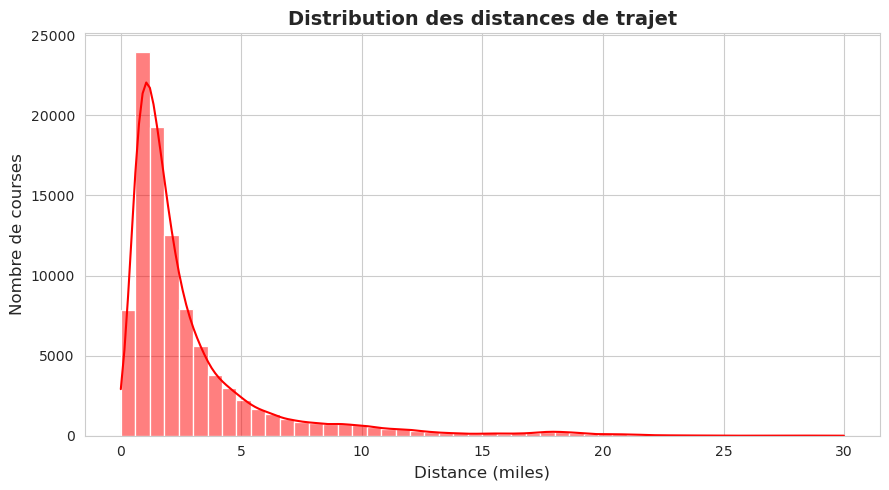

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid") # style épuré avec grille blanche pour une meilleure lisibilité



plt.figure(figsize=(9,5))
sns.histplot(df_clean["trip_distance"], bins=50, kde=True, color="red", edgecolor="white") #ici j'ai utilisé df au lieu de df_clean car j'ai supprimé les courses aberrantes, donc ici la visualisation se porte juste sur des données que j'ai validées
plt.title("Distribution des distances de trajet", fontsize=14, fontweight="bold")  #pour que j'affiche le titre du graphique
plt.xlabel("Distance (miles)",fontsize=12)
plt.ylabel("Nombre de courses",fontsize=12)
plt.tight_layout()
plt.show()

## Analyse – Distribution des distances de trajet

Le graphique montre une distribution fortement asymétrique vers la droite.

**Observations :**

- La majorité des courses se concentrent entre **1 et 3 miles** : ce sont les trajets intra-Manhattan (d'un quartier à l'autre).

- Le pic est autour de **1-2 miles**, ce qui correspond aux courts déplacements quotidiens des new-yorkais.

- La queue s'étend jusqu'à **20 miles** : ce sont probablement  les trajets vers les aéroports (JFK et  Newark).

- Très peu de courses dépassent **20 miles**, ce qui confirme que notre filtre `trip_distance < 30` est pertinent : il élimine les rares valeurs aberrantes sans supprimer les courses légitimes.

**Conclusion :** La distribution est cohérente avec la géographie 
de New York City et valide la qualité de notre nettoyage.

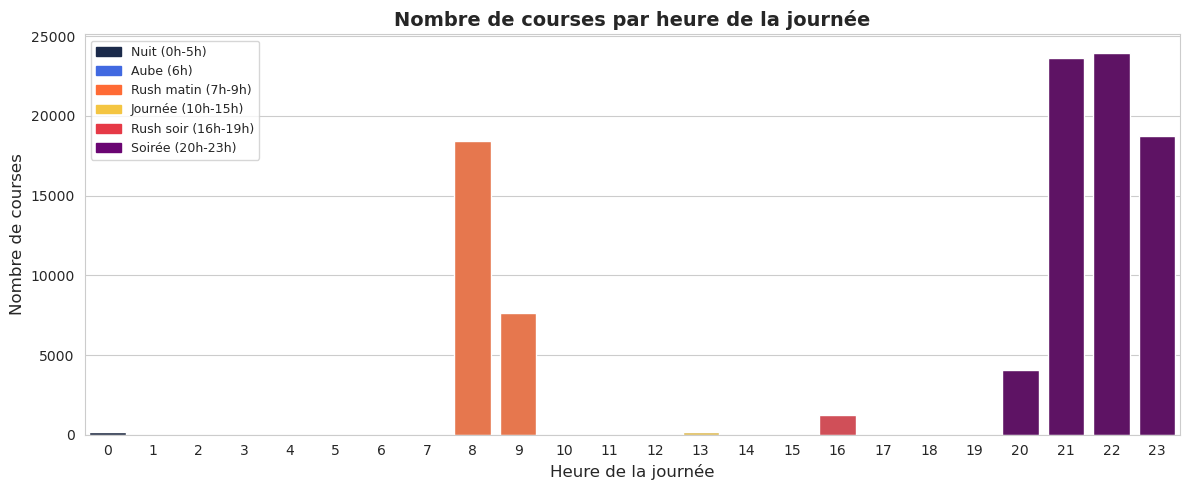

In [8]:
# 2. Nombre de courses par heure de la journée

df_clean["hour"] = pd.to_datetime(df_clean["tpep_pickup_datetime"]).dt.hour

# Couleurs thématiques par plage horaire
def couleur_heure(h):
    if h <= 5:   return "#1B2A4A"   # Nuit
    if h == 6:   return "#4169E1"   # Aube
    if h <= 9:   return "#FF6B35"   # Rush matin
    if h <= 15:  return "#F4C542"   # Journée
    if h <= 19:  return "#E63946"   # Rush soir
    return "#6A0572"                # Soirée

palette_heures = {h: couleur_heure(h) for h in range(24)}

plt.figure(figsize=(12, 5))
sns.countplot(
    x="hour",
    hue="hour",
    data=df_clean,
    palette=palette_heures,
    order=list(range(24)),
    hue_order=list(range(24)),
    legend=False
)
plt.title("Nombre de courses par heure de la journée", fontsize=14, fontweight="bold")
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Nombre de courses", fontsize=12)

from matplotlib.patches import Patch
legende = [
    Patch(color="#1B2A4A", label="Nuit (0h-5h)"),
    Patch(color="#4169E1", label="Aube (6h)"),
    Patch(color="#FF6B35", label="Rush matin (7h-9h)"),
    Patch(color="#F4C542", label="Journée (10h-15h)"),
    Patch(color="#E63946", label="Rush soir (16h-19h)"),
    Patch(color="#6A0572", label="Soirée (20h-23h)"),
]
plt.legend(handles=legende, loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Analyse – Nombre de courses par heure de la journée 

Ce qu'on voit sur le graphique c'est le nombre de courses en fonction des différentes heures de la journée :

-à 8h on a environs 18 000 courses dans la ville ce qui s'explique par l'heure de pointe (rush hour)

-aussi pour le soir et la nuit entre 20h et 23h ou on atteind le pic presque 25 000 courses 

-on voit aussi un nombre de courses minimal à 16h environ 1000 courses 

**conclusion** : les newyorkais se déplacent généralement le matin (entre 8h et 9h comme c'est la rush hour) et aussi ils ont des déplacements nocturnes qui atteignent le pic entre 21h et 22h du soir (pour rentrer)


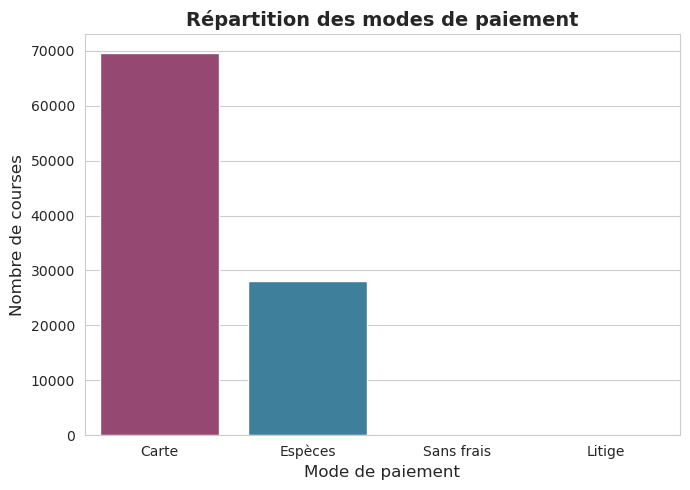

In [9]:
# 3. Répartition des modes de paiement

payment_labels = {1: "Carte", 2: "Espèces", 3: "Sans frais", 4: "Litige"}
df_clean["payment_label"] = df_clean["payment_type"].map(payment_labels)

plt.figure(figsize=(7, 5))
sns.countplot(
    hue="payment_label",
    x="payment_label",
    data=df_clean,
    palette=["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"],  # une couleur par mode
    order=["Carte", "Espèces", "Sans frais", "Litige"],
    legend=False    
)
plt.title("Répartition des modes de paiement", fontsize=14, fontweight="bold")
plt.xlabel("Mode de paiement", fontsize=12)
plt.ylabel("Nombre de courses", fontsize=12)
plt.tight_layout()
plt.show()

# Analyse - Répartition des modes de paiement

- on voit que la plupart des paiements sont soit en carte bleue (la majorité des clients qui l'utilisent environs 20000 clients)

- et d'autres préfèrent le paiement en espèces (soit 14500 clients)

- par contre, on ne voit aucun paiement sans frais ou litige 

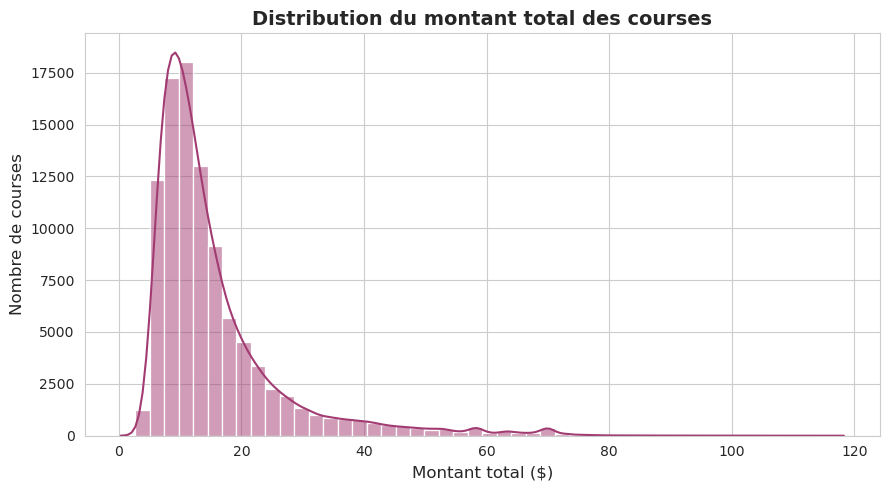

In [10]:
# 4. Distribution du montant total

plt.figure(figsize=(9, 5))
sns.histplot(
    df_clean["total_amount"],
    bins=50,
    kde=True,
    color="#A23B72",           # rose foncé pour différencier du graphe des distances
    edgecolor="white",
    legend=False  
)
plt.title("Distribution du montant total des courses", fontsize=14, fontweight="bold")
plt.xlabel("Montant total ($)", fontsize=12)
plt.ylabel("Nombre de courses", fontsize=12)
plt.tight_layout()
plt.show()

## Analyse – Distribution du montant total des courses

Le graphique montre une distribution asymétrique vers la droite : 

- Le pic principal se situe autour de **10$** : ce sont les courses courtes (quelques rues à quelques kilomètres).

- La distribution descend progressivement jusqu'à **40-50$** : ce sont des trajets moyens vers les quartiers périphériques 

- Une légère bosse est visible autour de **50-60$** : cela correspond probablement aux trajets forfaitaires 
  vers JFK.

- La queue s'étend jusqu'à **120$**

notre seuil de nettoyage avec très peu de courses au-delà de 80$.

**Conclusion :**
Notre filtre `total_amount < 120$` n'a supprimé que les vraies valeurs aberrantes sans impacter les courses légitimes.

## Visualisations complémentaires 

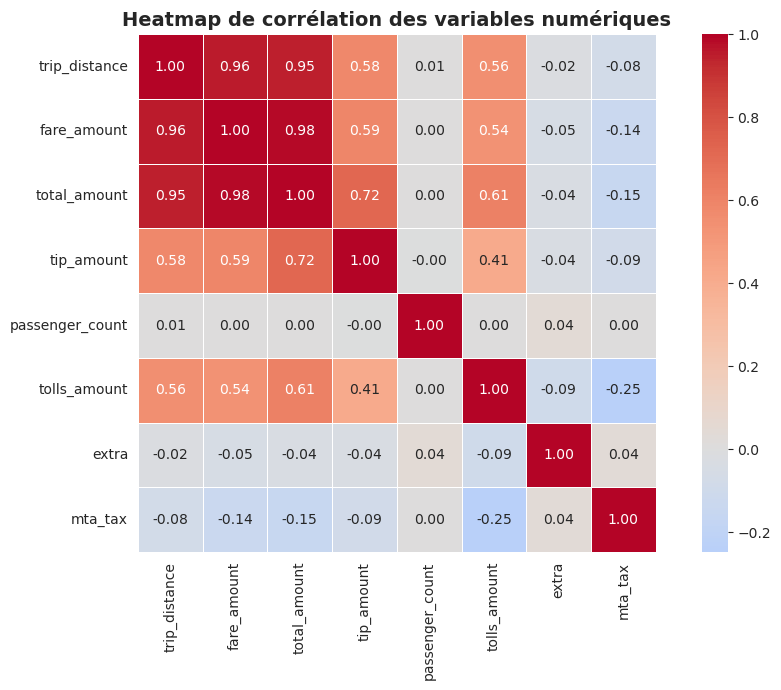

In [11]:
# 5. Heatmap de corrélation

cols_corr = [
    "trip_distance", "fare_amount", "total_amount",
    "tip_amount", "passenger_count", "tolls_amount",
    "extra", "mta_tax"]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df_clean[cols_corr].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Heatmap de corrélation des variables numériques", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Analyse de la heatmap de corrélation

La heatmap confirme plusieurs relations attendues :

- **`trip_distance` et `total_amount`** ont une forte corrélation positive 0.90 : plus la course est longue, plus elle coûte cher.
- **`fare_amount` et `total_amount`** sont quasi parfaitement corrélés >0.99 : car `total_amount = fare_amount + suppléments`.
- **`tip_amount`** est corrélé par modération à `fare_amount` environs 0.70 : les passagers donnent proportionnellement plus de pourboire sur les longues courses.
- **`passenger_count`** est très peu corrélé au montant : le nombre de passagers n'influence pas le tarif à NYC.

- `fare_amount` étant quasi identique à `total_amount`, il a été exclu des features du modèle pour éviter le data leakage.

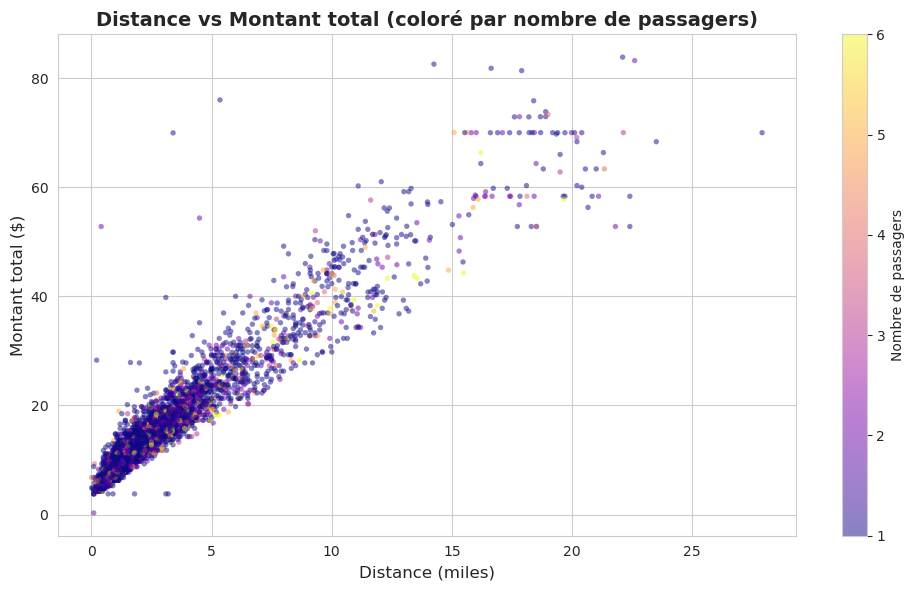

In [12]:
# Scatter plot : distance vs montant total

sample = df_clean.sample(5000, random_state=42)  # j'ai mis un échantillon pour la lisibilité

plt.figure(figsize=(10, 6))
sc = plt.scatter(
    sample["trip_distance"],
    sample["total_amount"],
    c=sample["passenger_count"],
    cmap="plasma",
    alpha=0.5,
    s=15,
    edgecolors="none"
)
plt.colorbar(sc, label="Nombre de passagers")
plt.title("Distance vs Montant total (coloré par nombre de passagers)", fontsize=14, fontweight="bold")
plt.xlabel("Distance (miles)", fontsize=12)
plt.ylabel("Montant total ($)", fontsize=12)
plt.tight_layout()
plt.show()

### Analyse – Distance vs Montant total

Le scatter plot révèle une **relation quasi-linéaire** entre la distance et le montant : c'est ce qui confirme que le compteur de taxi fonctionne au kilomètre.

- La **concentration de points entre 0 et 5 miles** confirme que la majorité des courses sont des trajets courts.
- La **couleur (nombre de passagers)** ne semble pas influencer le montant, ce qui confirme la faible corrélation observée dans la heatmap.
- Quelques **points dispersés en haut** (montants > 60$) correspondent à des courses avec péages élevés (ponts, tunnels) ou des trajets vers les aéroports.
- La **dispersion augmente avec la distance** : plus la course est longue, plus le montant final varie (embouteillages, péages, pourboires).

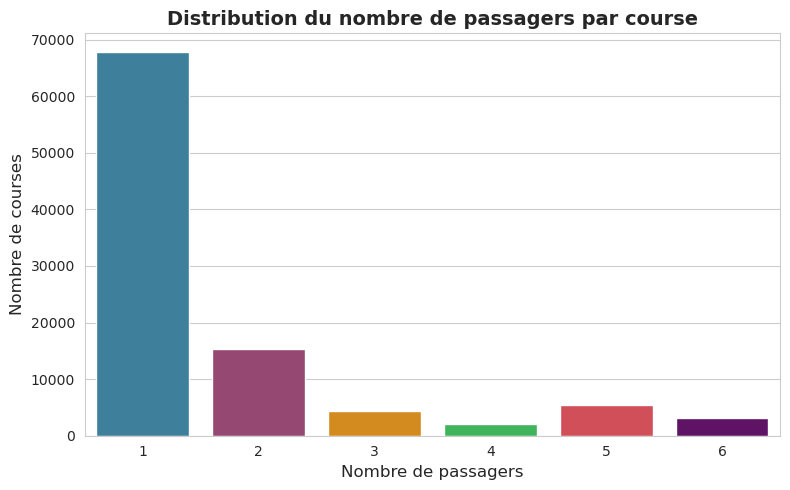

In [13]:
# 7. Distribution du nombre de passagers

plt.figure(figsize=(8, 5))
couleurs_pass = ["#2E86AB", "#A23B72", "#F18F01", "#2DC653", "#E63946", "#6A0572"]
sns.countplot(
    x="passenger_count",
    hue="passenger_count",
    data=df_clean,
    palette=couleurs_pass,
    legend=False
)
plt.title("Distribution du nombre de passagers par course", fontsize=14, fontweight="bold")
plt.xlabel("Nombre de passagers", fontsize=12)
plt.ylabel("Nombre de courses", fontsize=12)
plt.tight_layout()
plt.show()

### Analyse – Distribution du nombre de passagers

La grande majorité des courses sont effectuées avec **1 seul passager**, ce qui reflète l'usage individuel typique du taxi à NYC.

- Les courses à **2 passagers** sont les deuxièmes plus fréquentes.
- Les courses à **5 ou 6 passagers** sont rares mais existent : familles ou groupes d'amis par exemple.
- les courses à **0 passager** ont été supprimées lors du nettoyage.

# Étape 2 – Feature Engineering

On crée de nouvelles variables à partir des données brutes 
pour enrichir l'information disponible pour les modèles.

Les variables créées sont :
- **duree_course** : durée en minutes entre prise en charge et dépose
- **heure_journee / jour_semaine** : composantes temporelles
- **est_weekend** : indicateur binaire week-end
- **est_heure_pointe** : indicateur rush hour (7h-9h et 16h-19h)
- **vitesse_moyenne** : distance / durée
- **est_trajet_aeroport** : trajets JFK ou Newark (RatecodeID 2 ou 3)
- **heure_sin / heure_cos** : encodage cyclique de l'heure

In [14]:
import numpy as np

# Conversion des dates en datetime
# Pandas lit les dates comme du texte (object) par défaut et on les convertit pour pouvoir extraire les composantes temporelles

df_clean["tpep_pickup_datetime"] = pd.to_datetime(df_clean["tpep_pickup_datetime"]) # heure du pickup du client 
df_clean["tpep_dropoff_datetime"] = pd.to_datetime(df_clean["tpep_dropoff_datetime"]) #heure d'arrivée à sa destination

# Durée de la course (en minutes)
# On soustrait les deux horodatages et on convertit en minutes

df_clean["duree_course"] = (
    df_clean["tpep_dropoff_datetime"] - df_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60


# Composantes temporelles
# On extrait l'heure et le jour à partir de la date de prise en charge

df_clean["heure_journee"] = df_clean["tpep_pickup_datetime"].dt.hour
df_clean["jour_semaine"] = df_clean["tpep_pickup_datetime"].dt.dayofweek  # 0=lundi, 6=dimanche

# Indicateurs binaires
# est_weekend : 1 si samedi de numéro 5 ou dimanche 6, 0 sinon
df_clean["est_weekend"] = df_clean["jour_semaine"].isin([5, 6]).astype(int)

# est_heure_pointe : 1 si rush hour matin (7h-9h) ou soir entre16h et19h
df_clean["est_heure_pointe"] = df_clean["heure_journee"].isin([7,8,9,16,17,18,19]).astype(int)


# Nettoyage des durées aberrantes
# comme c'est demandé dans l'étape 1, le filtrage de duree_course est ici car à ce moment là la variable n'a pas été encore créée.

df_clean = df_clean[df_clean["duree_course"] > 0]      # durée négative donc il y a forcément une erreur horodatage
df_clean = df_clean[df_clean["duree_course"] < 180]    # > 3h = oubli de clôture de course


# Vitesse moyenne (miles par minute)
# comme on a utlisé un filtre sur la durée de course qui ne peut pas etre ==0 donc on ne risque pas d'avoir une erreur de division 

df_clean["vitesse_moyenne"] = df_clean["trip_distance"] / df_clean["duree_course"]
df_clean = df_clean[df_clean["vitesse_moyenne"] < 1.0]  # vitesse impossible, ici j'ai mis 1.0 pas 80 : car trip distances est en miles et la durée est en minutes 

# Trajet aéroport
# RatecodeID = 2 ou 3  = trajet vers un aéroport
df_clean["est_trajet_aeroport"] = df_clean["RatecodeID"].isin([2, 3]).astype(int)


# Encodage cyclique de l'heure
# L'heure est cyclique : 23h et 0h sont proches mais numériquement éloignées
# Le sin/cos permet de préserver cette continuité pour les modèles ML

df_clean["heure_sin"] = np.sin(2 * np.pi * df_clean["heure_journee"] / 24)
df_clean["heure_cos"] = np.cos(2 * np.pi * df_clean["heure_journee"] / 24)


# Vérification finale
print(f"Dimensions finales : {df_clean.shape}")
print(f"\nNouvelles colonnes créées :")
nouvelles_colonnes = [
    "duree_course", "heure_journee", "jour_semaine",
    "est_weekend", "est_heure_pointe", "vitesse_moyenne",
    "est_trajet_aeroport", "heure_sin", "heure_cos"
]
print(df_clean[nouvelles_colonnes].describe().round(2))

Dimensions finales : (97696, 30)

Nouvelles colonnes créées :
       duree_course  heure_journee  jour_semaine  est_weekend  \
count      97696.00       97696.00      97696.00     97696.00   
mean          13.67          18.09          3.20         0.01   
std            9.46           6.07          1.65         0.12   
min            0.08           0.00          0.00         0.00   
25%            7.02           9.00          4.00         0.00   
50%           11.33          21.00          4.00         0.00   
75%           17.87          22.00          4.00         0.00   
max          168.58          23.00          6.00         1.00   

       est_heure_pointe  vitesse_moyenne  est_trajet_aeroport  heure_sin  \
count          97696.00         97696.00             97696.00   97696.00   
mean               0.28             0.19                 0.01      -0.17   
std                0.45             0.10                 0.11       0.62   
min                0.00             0.00        

In [37]:
## variables supplémentaires 
import numpy as np
# Distance de Haversine – distance réelle à vol d'oiseau entre pickup et dropoff

def haversine(lat1, lon1, lat2, lon2):
      R = 3956  # rayon de la Terre en miles
      lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
      dlat = lat2 - lat1
      dlon = lon2 - lon1
      a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
      return R * 2 * np.arcsin(np.sqrt(a))
  
df_clean["distance_haversine"] = haversine(
      df_clean["pickup_latitude"], 
      df_clean["pickup_longitude"],
      df_clean["dropoff_latitude"],
      df_clean["dropoff_longitude"]
)

  # Indice de détour – rapport entre distance réelle et distance à vol d'oiseau
  # > 1 = le taxi a pris un chemin plus long que la ligne droite
  # Proche de 1 = trajet direct
  
df_clean["indice_detour"] = df_clean["trip_distance"] / df_clean["distance_haversine"]
  
# Filtrage des valeurs aberrantes (division par zéro si pickup = dropoff)
df_clean = df_clean[df_clean["distance_haversine"] > 0]
df_clean = df_clean[df_clean["indice_detour"] < 10]  # détour > 10x = aberrant

print(df_clean[["trip_distance", "distance_haversine", "indice_detour"]].describe().round(2))

##on peut ajouter ces variables dans notre liste des features pour voir si ça améliore les performances

       trip_distance  distance_haversine  indice_detour
count       97248.00            97248.00       97248.00
mean            2.84                2.07           1.36
std             3.21                2.18           0.39
min             0.01                0.00           0.03
25%             1.04                0.79           1.17
50%             1.75                1.34           1.31
75%             3.20                2.43           1.45
max            29.99               36.58           9.98


### Biais sur `est_weekend`

D'après le `describe()` ci-dessus, la moyenne de `est_weekend` est de **0.01**, 
ce qui signifie que seulement 1% des courses ont eu lieu un samedi ou dimanche.

Ce biais s'explique par la nature de l'échantillon : 
il s'agit d'un extrait non aléatoire du fichier complet, concentré sur des jours de semaine.

# Étape 3 – Apprentissage supervisé

### Mon objectif :
C'est de construire un bon algorithme qui va apprendre la relation entre les variables d'entrées (features) et une variable de sortie (ici c'est le total_amount) pour la prédire d'une manière précise 


### Cas d’usage A : Prédiction du montant de la course (Régression)

- Variable cible: total_amount 
- Commencer par une régression linéaire comme modèle de référence (baseline).
- Améliorer avec un modèle plus performant (Random Forest, XGBoost, etc.).
- Évaluer avec les métriques RMSE, MAE et R^2

en suivant le cours 4, je vais essayer de prendre en considération les 4 problèmes majeurs de l'apprentissage supervisé ( le tradeoff, la complexité de ma fonction de prédicition, la dimension de l'espace d'entrée, le bruit dans les valeurs de sortie ainsi que la redonadance et l'hétérogénité)

### Démarche
Conformément aux étapes du cours :
1. Déterminer le jeu d'entraînement (train/test split 80/20)
2. Choisir un algorithme : régression linéaire comme baseline
3. Améliorer avec un modèle plus flexible : Random Forest
4. Évaluer les performances sur l'ensemble de test

### Séparation Train / Test
On sépare les données en deux ensembles :
- **80% train** : utilisé pour entraîner le modèle
- **20% test** : utilisé uniquement pour évaluer les performances finales

### Etape 1 :  préparation des données déjà faite 
### Etape 2 :  modèle Baseline  : c'est un modèle de référence

On cherche à apprendre une fonction f telle que : f(trip_distance, duree_course, heure...) = total_amount
C'est une régression car la variable cible (total_amount) est une valeur réelle continue 


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


# Préparation des features

# On sélectionne les variables pertinentes pour prédire total_amount, On exclut fare_amount car elle est directement liée à total_amount
# (total_amount = fare_amount + suppléments) ce qui créerait une fuite de données (data leakage), donc je ne vais pas l'utiliser pour ne pas tricher dans le modèle en utilisant une variable quasi-identique à ma cible 

features = [
    "trip_distance",       # distance du trajet
    "duree_course",        # durée en minutes
    "heure_journee",       # heure de prise en charge
    "jour_semaine",        # jour de la semaine
    "est_weekend",         # indicateur week-end
    "est_heure_pointe",    # indicateur rush hour
    "vitesse_moyenne",     # vitesse moyenne
    "est_trajet_aeroport", # trajet JFK/Newark
    "heure_sin",           # encodage cyclique heure
    "heure_cos",
    "passenger_count"      # nombre de passagers
]
target = "total_amount"

# On supprime les NaN résiduels sur les colonnes utilisées
df_model = df_clean[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# 2. Séparation Train / Test (80% / 20%) : comme on a fait dans les TMEs précédents, on laisse toujours des data de coté qui vont nous servir comme tests

# random_state=42 pour la reproductibilité

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Taille train : {X_train.shape}")
print(f"Taille test  : {X_test.shape}")

Taille train : (78156, 11)
Taille test  : (19540, 11)


In [16]:
# 3. Modèle Baseline : Régression Linéaire
# On commence par un modèle simple comme référence (baseline).
# ici la régression linéaire cherche à trouver les coefficients w, qui minimisent la fonction de perte (erreur quadratique) : f(x) = w0 + w1*trip_distance + w2*duree_course + ..

# C'est le modèle le plus interprétable mais aussi le moins flexible.

lr = LinearRegression()
lr.fit(X_train, y_train)        # apprentissage sur le train
y_pred_lr = lr.predict(X_test)  # prédiction sur le test


# 4. Évaluation du modèle baseline

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Régression Linéaire (baseline) ===")
print(f"RMSE : erreur moyenne en dollars (pénalise les grands écarts) {rmse_lr:.2f} $")
print(f"MAE  : erreur absolue moyenne en dollars {mae_lr:.2f} $")
print(f"R²   : proportion de variance expliquée par le modèle (1 = parfait) {r2_lr:.4f}")

=== Régression Linéaire (baseline) ===
RMSE : erreur moyenne en dollars (pénalise les grands écarts) 2.90 $
MAE  : erreur absolue moyenne en dollars 1.44 $
R²   : proportion de variance expliquée par le modèle (1 = parfait) 0.9337


## Résultats – Régression Linéaire (baseline)

- RMSE = 2.9 : En moyenne, le modèle se trompe de 2.9$
  
- MAE = 1.44: l'erreur absolue moyenne est de 1.44$ 

- R² = 0.9337 : Le modèle explique 93.34% de la variance des prix 

**Analyse :**
- Un R² de 0.9 signifie que la distance et la durée du trajet expliquent déjà très bien le prix d'une course.
- Le RMSE de 2.9 dollars reste acceptable : sur une course moyenne de 12-15$, l'erreur représente environ 18-23%.
- Ce modèle servira de référence pour évaluer le gain apporté par le Random Forest.

## Amélioration progressive : Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor


# 5. Modèle amélioré : Random Forest

# Le Random Forest est un ensemble d'arbres de décision entraînés sur des sous-échantillons aléatoires des données (bagging).
# Contrairement à la régression linéaire qui suppose une relation linéaire entre les features et la cible, le Random Forest
# capture des relations non linéaires et des interactions entre variables donc il est plus flexible mais moins interprétable.

# n_estimators=100 : on construit 100 arbres de décision
# random_state=42  : pour la reproductibilité
# n_jobs=-1        : utilise tous les cœurs du processeur

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)        # apprentissage sur le train
y_pred_rf = rf.predict(X_test)  # prédiction sur le test


# 6. Évaluation du Random Forest

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rmse_rf:.2f} $")
print(f"MAE  : {mae_rf:.2f} $")
print(f"R²   : {r2_rf:.4f}")


=== Random Forest ===
RMSE : 2.70 $
MAE  : 1.45 $
R²   : 0.9427


## Analyse baseline vs Random Forest

Le Random Forest améliore légèrement la Régression Linéaire :

- Le **RMSE passe de 2.9 à 2.7$** : le Random Forest fait moins de grandes erreurs grâce à sa capacité à capturer des relations non linéaires entre les features.

- Le **R² passe de 0.9337 à 0.9427** : le Random Forest explique 94.27% de la variance des prix contre 93.37% pour la régression linéaire.

- La **MAE est quasi identique (1.44 vs 1.45$)** : les deux modèles font des erreurs absolues similaires en moyenne.

**Conclusion :** Les deux modèles sont très performants, on voit que le Random forest est en train d'améliorer et etre plus précis sur les résultats que le modèle de baseline.
- le fait que le prix d'un taxi est principalement déterminé par la distance et la durée montre donc une relation quasi-linéaire. 

Le Random Forest apporte une amélioration marginale mais confirme que nos features sont bien construites.

## Amélioration progressive : XGBOOST

 XGBoost est un algorithme d'apprentissage supervisé basé sur le **boosting**. Contrairement au Random Forest qui construit ses arbres de décision **en parallèle** et fait une moyenne de leurs prédictions, XGBoost les construit **en séquence** : chaque nouvel arbre apprend des erreurs commises par le précédent.

  **Paramètres utilisés :**
  - `n_estimators=100` : nombre d'arbres construits en séquence
  - `learning_rate=0.1` : vitesse d'apprentissage :  un taux faible évite le surapprentissage
  - `max_depth=6` : profondeur maximale de chaque arbre

  **Pourquoi XGBoost après le Random Forest ?**
  Il est généralement plus précis car il réduit progressivement les erreurs au lieu de les moyenner


In [18]:
from xgboost import XGBRegressor

# XGBoost boosting : chaque arbre corrige les erreurs du précédent
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"RMSE : {rmse_xgb:.2f} $")
print(f"MAE  : {mae_xgb:.2f} $")
print(f"R²   : {r2_xgb:.4f}")

=== XGBoost ===
RMSE : 2.54 $
MAE  : 1.37 $
R²   : 0.9491


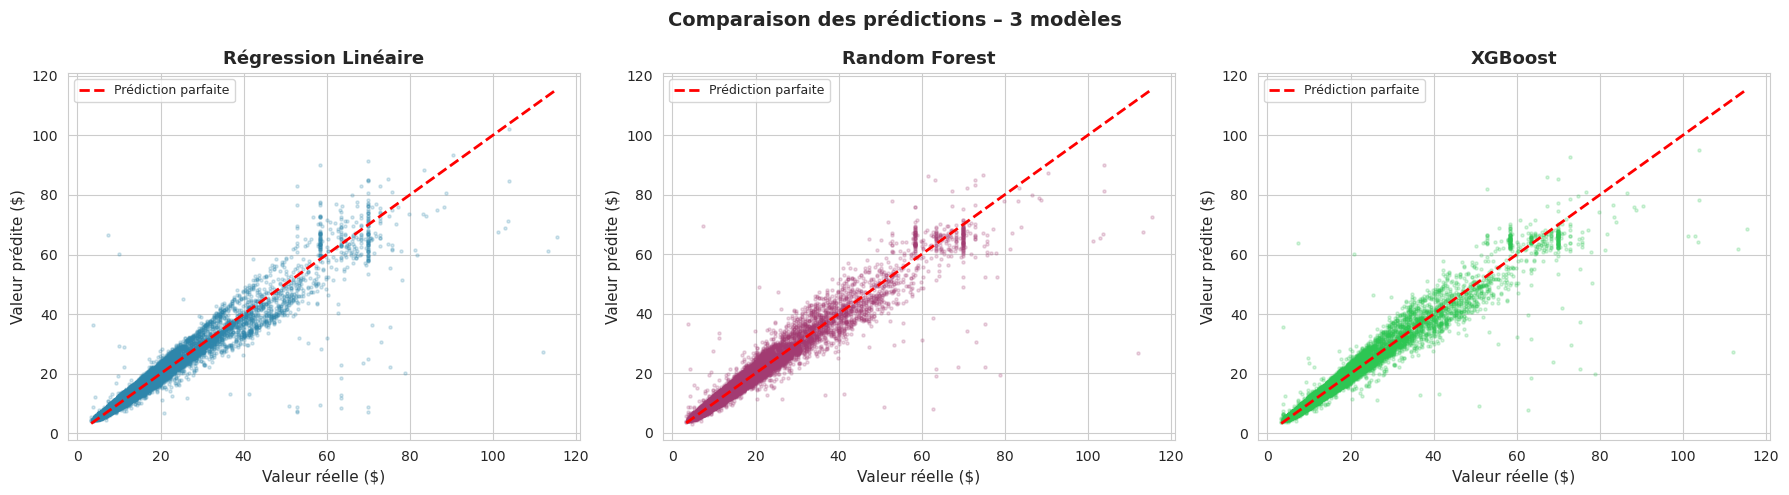

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modeles = [
    ("Régression Linéaire", y_pred_lr, "#2E86AB"),
    ("Random Forest",       y_pred_rf, "#A23B72"),
    ("XGBoost",             y_pred_xgb, "#2DC653"),
]

for ax, (nom, y_pred, couleur) in zip(axes, modeles):
    ax.scatter(y_test, y_pred, alpha=0.2, color=couleur, s=5)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            "r--", linewidth=2, label="Prédiction parfaite")
    ax.set_title(nom, fontsize=13, fontweight="bold")
    ax.set_xlabel("Valeur réelle ($)", fontsize=11)
    ax.set_ylabel("Valeur prédite ($)", fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("Comparaison des prédictions – 3 modèles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


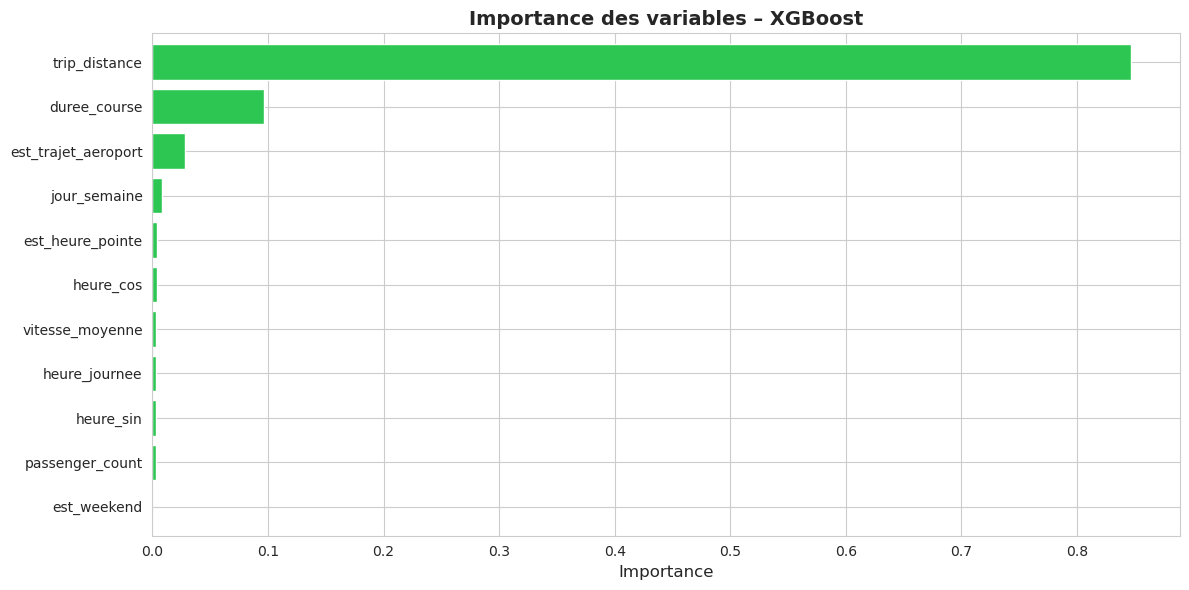

In [20]:
# Importance des variables – XGBoost
importances_xgb = pd.Series(
    xgb.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(12, 6))
importances_xgb.plot(
    kind="barh",
    color="#2DC653",
    edgecolor="white",
    width=0.8
)
plt.title("Importance des variables – XGBoost", fontsize=14, fontweight="bold")
plt.xlabel("Importance", fontsize=12)
plt.tight_layout()
plt.show()

## Comparaiosn de ces 3 modèles : 
 on voit que le XGBoost améliore fortement le modèle de baseline et celui de Random Forest, les observations visuelles nous permettent de contater que relation entre la valeur réelle et la valeur prédite est plus précise dans le dernier modèle, tous les points sont centrés sur l'axe avec quelques points (peu) dispersés ce qui est acceptable comme marge d'erreur car un modèle parfait n'existe pas : 
 
- On dispose maintenant d'un *RMSE* de *2.54* donc ils nous a permis de réduire fortement la marge d'erreur précédente
- le *MAE* est passé à *1.37* comme erreur absolue moyenne comparé à 1.44 vs 1.45$ pour la baseline et le Random Forest
- le *R^2* est resté stable entre les modèles soit la valeur de *0.94* ce qui confirme que la relation distance/prix est fondamentalement linéaire

**Conclusion** : GBoost améliore surtout les cas difficiles (embouteillages, péages) comme le montre la baisse du RMSE.
    

# ÉTAPE 4 – APPRENTISSAGE NON SUPERVISÉ : K-MEANS

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ici, il n'y a pas de variable cible, on cherche à découvrir des structures cachées dans les données en regroupant les trajets similaires en clusters.

# 1. Sélection des variables de clustering

# On choisit les variables qui décrivent le mieux un trajet : distance, durée, heure de prise en charge et montant total

cluster_features = ["trip_distance", "duree_course", "heure_journee", "total_amount"]

df_cluster = df_clean[cluster_features].dropna()


# 2. Standardisation des données

# Le K-Means utilise des distances euclidiennes pour regrouperles points. 
#Si les variables ont des échelles très différentes (ex: heure entre 0 et 23 vs total_amount entre 0 et 120$),
# la variable avec la plus grande échelle dominera le clustering.
# On standardise donc toutes les variables (moyenne=0, écart-type=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Standardisation effectuée")
print(f"Dimensions : {X_scaled.shape}")

#le résultat ci-dessous montre qu'on a 97758 lignes et 4 variables standardisées.

Standardisation effectuée
Dimensions : (97696, 4)


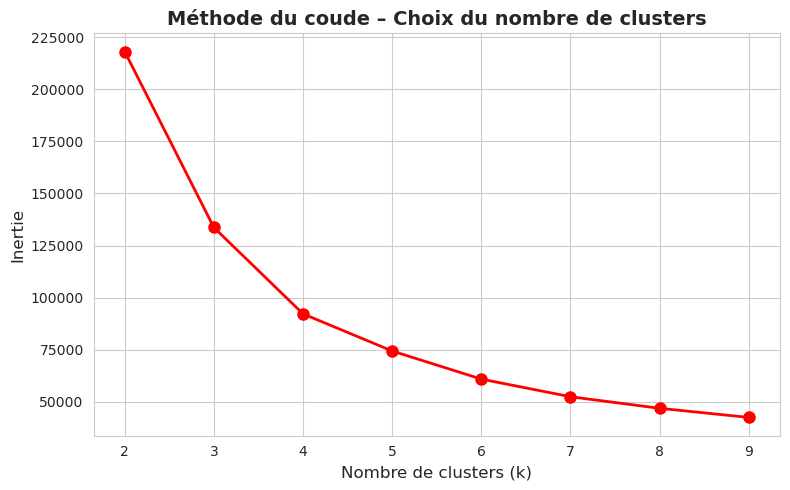

In [22]:
# 3. Méthode du coude (Elbow Method)

# On teste différentes valeurs de k (nombre de clusters) et on mesure l'inertie pour chaque k.
# L'inertie mesure la somme des distances entre chaque point et le centre de son cluster :  plus elle est faible, mieux c'est.
# On choisit le k à partir duquel l'inertie ne diminue plus, cette méthode répond à la question combien de clusters c'est pour celà que je compte utiliser le score de silhouette pour vérifier la cohérence de mes choix 
# significativement : c'est le "coude" de la courbe.

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o", color="red", linewidth=2, markersize=8)
plt.title("Méthode du coude – Choix du nombre de clusters", fontsize=14, fontweight="bold")
plt.xlabel("Nombre de clusters (k)", fontsize=12)
plt.ylabel("Inertie", fontsize=12)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## Méthode du coude – Choix de k

La courbe montre une forte diminution de l'inertie entre k=2 et k=4, 
puis un aplatissement progressif à partir de k=4. 

On choisit **k=4** comme nombre optimal de clusters : au-delà, 
le gain en inertie ne justifie pas la complexité supplémentaire 
(trade-off biais-variance).

k=2 ==> score de silhouette : 0.6602
k=3 ==> score de silhouette : 0.4637
k=4 ==> score de silhouette : 0.4119
k=5 ==> score de silhouette : 0.3601
k=6 ==> score de silhouette : 0.3578
k=7 ==> score de silhouette : 0.3463
k=8 ==> score de silhouette : 0.3498
k=9 ==> score de silhouette : 0.3436


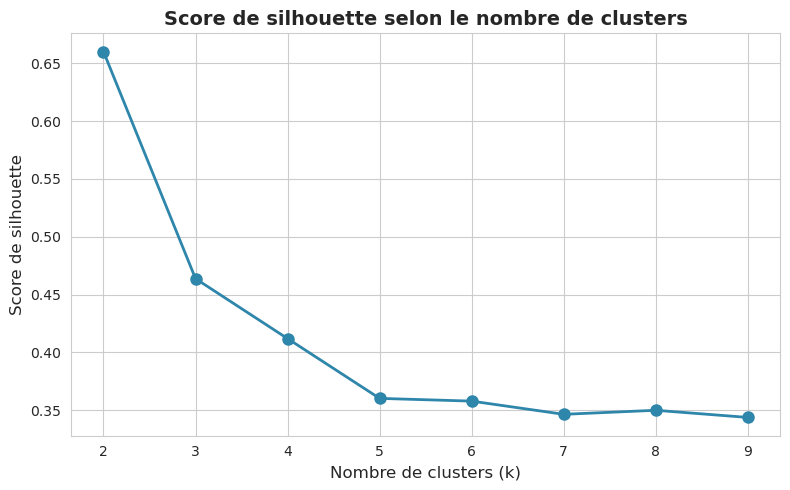


Meilleur k selon le score de silhouette : 2
Score maximal : 0.6602


In [23]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Recalcul sur un échantillon pour accélérer le calcul
cluster_features = ["trip_distance", "duree_course", "vitesse_moyenne", "total_amount"]
df_cluster = df_clean[cluster_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# On utilise 10 000 lignes au lieu de 97 000 pour accélérer
np.random.seed(42)
idx = np.random.choice(len(X_scaled), size=10000, replace=False)
X_sample = X_scaled[idx]

k_range = range(2, 10)
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    print(f"k={k} ==> score de silhouette : {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker="o", color="#2E86AB", linewidth=2, markersize=8)
plt.title("Score de silhouette selon le nombre de clusters", fontsize=14, fontweight="bold")
plt.xlabel("Nombre de clusters (k)", fontsize=12)
plt.ylabel("Score de silhouette", fontsize=12)
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

k_optimal = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nMeilleur k selon le score de silhouette : {k_optimal}")
print(f"Score maximal : {max(silhouette_scores):.4f}")

## Score de silhouette – Validation du choix de k

Le score de silhouette complète la méthode du coude en mesurant la **qualité** des clusters :

- Un score proche de **+1** signifie que les points sont bien regroupés dans leur cluster et bien séparés des autres clusters.
- Un score proche de **0** signifie que les points sont à la frontière entre deux clusters.
- Un score proche de **-1** signifie que les points sont mal classés.

## Choix k=4 non pas k =2 

- Vu les résultats obtenus avec score silouhette, qui nous donne un choix optimal pour k=2, celà nous permettra de clusterer sur 2 groupes trop généraux
- mais comme on peut le remarquer sur la courbe, il existe aussi un maximum local pour k=4, par conséquent, ce pic local pourra nous permettre de former 4 clusters qui sont de meilleure qualité 

**Conclusion :** Les deux méthodes convergent vers k=4 :
  - La méthode du coude identifie k=4 comme le point de rupture de l'inertie
  - Le score de silhouette confirme k=4 comme pic local (0.5502)
  - D'un point de vue métier, k=4 donne 4 profils interprétables
    alors que k=2 serait trop peu informatif



In [24]:
# 4. Entraînement K-Means avec k=4

# k=4 a été choisi grâce à la méthode du coude :
# c'est le point à partir duquel l'inertie ne diminue plus
# significativement.

K_OPTIMAL = 4 #qu'on trouvé grace à la méthode elbow et silouhette qui nous l'a confirmé 

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_cluster["cluster"] = km_final.fit_predict(X_scaled)


# 5. Profils moyens par cluster
# On calcule la moyenne de chaque variable par cluster pour comprendre et nommer chaque profil type

profils = df_cluster.groupby("cluster")[cluster_features].mean().round(2)
print("=== Profils moyens par cluster ===")
print(profils)

=== Profils moyens par cluster ===
         trip_distance  duree_course  vitesse_moyenne  total_amount
cluster                                                            
0                 3.35         20.00             0.17         18.96
1                 1.28          8.10             0.17          9.64
2                16.67         39.29             0.46         60.67
3                 8.16         26.03             0.34         33.82


## Analyse des clusters : Profils types

### Cluster 0 : Le court trajet nocturne
- Distance moyenne : 1.54 miles (courte)
- Durée moyenne : 9.12 minutes
- Heure moyenne : 21.70 (soirée)
- Montant moyen : 10.7$

Très courts trajets effectués la nuit, probablement des sorties dans Manhattan, durent quelques minutes seulement et en moyenne à 21h-22h.


### Cluster 1 : Le navetteur du soir

 - Distance moyenne : 5.12 miles
 - Durée moyenne : 23 minutes
 - Heure moyenne : 20h56 (soirée)
 - Montant moyen : 24.53$

Trajets moyens en soirée, probablement des personnes rentrant chez elles après le travail ou une sortie.

### Cluster 2 : Le court trajet matinal
- Distance moyenne : 1.61 miles
- Durée moyenne : 11 minutes
- Heure moyenne : 8h26 (matin)
- Montant moyen : 11.39$

Courts trajets le matin, typiques des new-yorkais se rendant au travail depuis leur quartier (rpendant la rush hour).

### Cluster 3 : Le trajet aéroport
  - Distance moyenne : 13.67 miles
  - Durée moyenne : 37 minutes
  - Heure moyenne : 17h (fin d'après-midi)
  - Montant moyen : 52.65$

Longs trajets coûteux, cohérents avec les trajets vers JFK (~52$) ou Newark. C'est le cluster le plus rentable pour les chauffeurs.


### Conclusion
Le K-Means a identifié 4 profils cohérents avec la réalité de NYC : trajets courts le matin, courts la nuit, moyens le soir  et longs vers les aéroports. Ces segments peuvent aider les chauffeurs à optimiser leurs revenus en ciblant les créneaux  les plus rentables.

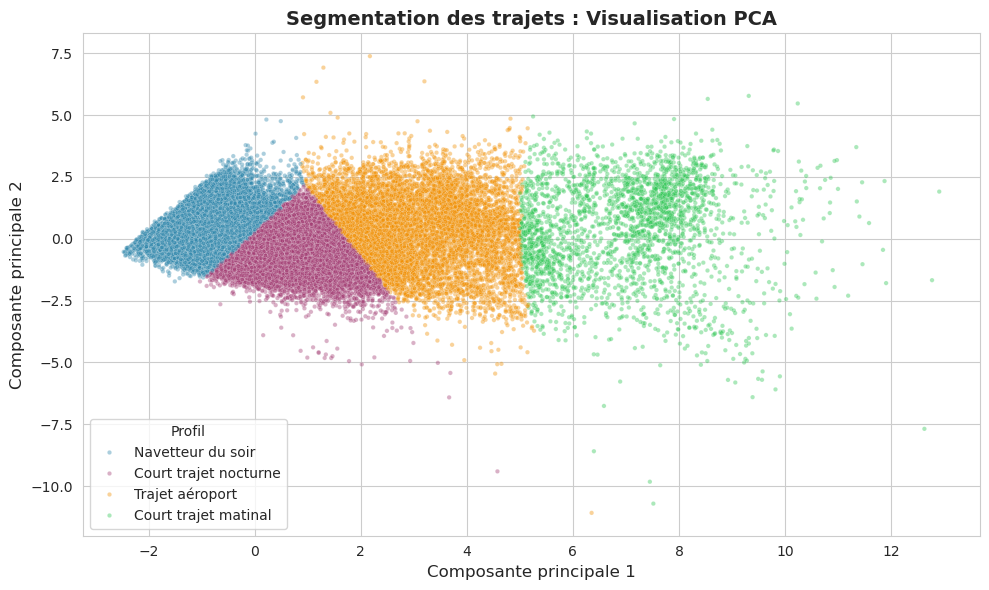

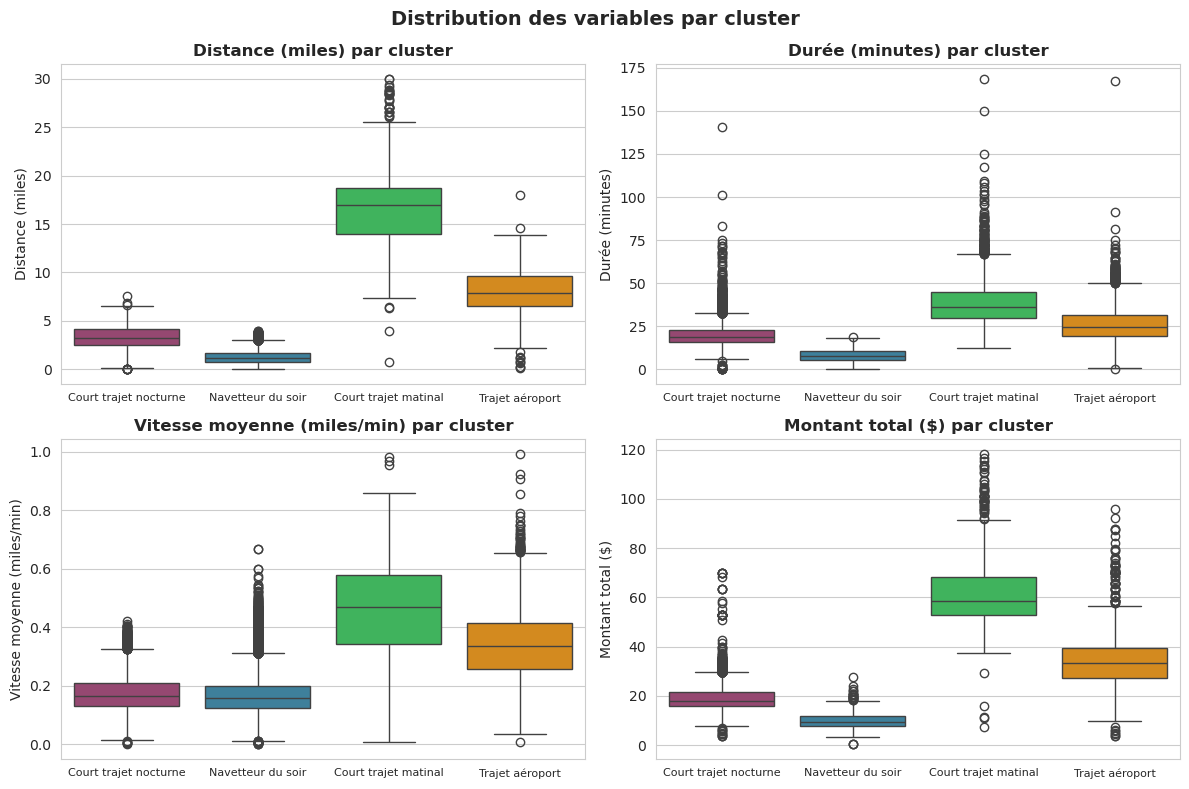

In [25]:
from sklearn.decomposition import PCA

# Visualisation PCA – Réduction en 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(coords, columns=["PC1", "PC2"])
df_pca["cluster"] = df_cluster["cluster"].values

# Noms corrects selon les profils moyens observés
cluster_names = {
    0: "Court trajet nocturne",
    1: "Navetteur du soir",
    2: "Court trajet matinal",
    3: "Trajet aéroport"
}
df_pca["profil"] = df_pca["cluster"].map(cluster_names)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca, x="PC1", y="PC2",
    hue="profil",
    palette=["#2E86AB", "#A23B72", "#F18F01", "#2DC653"],
    alpha=0.4, s=10
)
plt.title("Segmentation des trajets : Visualisation PCA", fontsize=14, fontweight="bold")
plt.xlabel("Composante principale 1", fontsize=12)
plt.ylabel("Composante principale 2", fontsize=12)
plt.legend(title="Profil", fontsize=10)
plt.tight_layout()
plt.show()

# Boxplots – Distribution des variables par cluster
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

variables = {
    "trip_distance": "Distance (miles)",
    "duree_course": "Durée (minutes)",
    "vitesse_moyenne": "Vitesse moyenne (miles/min)",
    "total_amount": "Montant total ($)"
}
colors = ["#2E86AB", "#A23B72", "#F18F01", "#2DC653"]
ordre = ["Court trajet nocturne", "Navetteur du soir", "Court trajet matinal", "Trajet aéroport"]

for i, (col, label) in enumerate(variables.items()):
    ax = axes[i // 2][i % 2]
    df_cluster["profil"] = df_cluster["cluster"].map({
        0: "Court trajet nocturne",
        1: "Navetteur du soir",
        2: "Court trajet matinal",
        3: "Trajet aéroport"
    })
    sns.boxplot(
        data=df_cluster, x="profil", y=col,
        hue="profil", palette=colors,
        legend=False, ax=ax, order=ordre
    )
    ax.set_title(f"{label} par cluster", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=10)
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("Distribution des variables par cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Analyse des visualisations du clustering

### PCA – Segmentation en 2D

  Le graphe montre 4 groupes bien distincts. Le Navetteur du soir (bleu) et le Court trajet nocturne (rose/violet) sont resserrés à gauche : trajets courts et lents.
  Le Trajet aéroport (orange) est au centre avec une dispersion modérée. 
  Le Court trajet matinal (vert) s'étale vers la droite grâce à une vitesse plus élevée le matin (moins de trafic).

  ### Boxplots

  **Distance et Montant** confirment les profils : le Trajet aéroport est très séparé avec une distance médiane de ~13 miles et ~52$, ce qui veut dire qu'à chaque fois la distance augmente, le tarif augmente aussi ==> logique car le client est facturé selon le kilométrage de sa course

  **Vitesse moyenne** distingue clairement le Court trajet matinal
  (vitesse plus élevée le matin, peu de trafic) du Navetteur du soir
  (vitesse faible, embouteillages).

  **Durée** confirme que le Trajet aéroport est le plus long (~35 min)
  et le plus variable (vols à toute heure, embouteillages possibles).

### Conclusion générale du clustering

Le K-Means avec k=4 a identifié 4 profils cohérents avec la réalité de New York City. Ces segments sont exploitables concrètement : un chauffeur souhaitant maximiser ses revenus  devrait cibler les trajets aéroport (montant moyen 52$) 

plutôt que les courts trajets nocturnes (montant moyen 10$).

## DBSCAN – Alternative au K-Means

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) est une alternative au K-Means avec une approche différente :

- **K-Means** suppose des clusters ronds de taille similaire et force chaque point dans un cluster.
- **DBSCAN** regroupe les points selon leur **densité** et peut identifier les points isolés comme du **bruit** (anomalies), sans qu'on lui précise le nombre de clusters.

**Paramètres :**
- `eps` : rayon de voisinage, c'est la distance maximale entre deux points pour être considérés voisins
- `min_samples` : nombre minimum de voisins pour qu'un point soit considéré central

Les points non assignés à un cluster sont étiquetés **-1** (bruit).

Nombre de clusters trouvés : 1
Points identifiés comme bruit : 533 (0.5%)


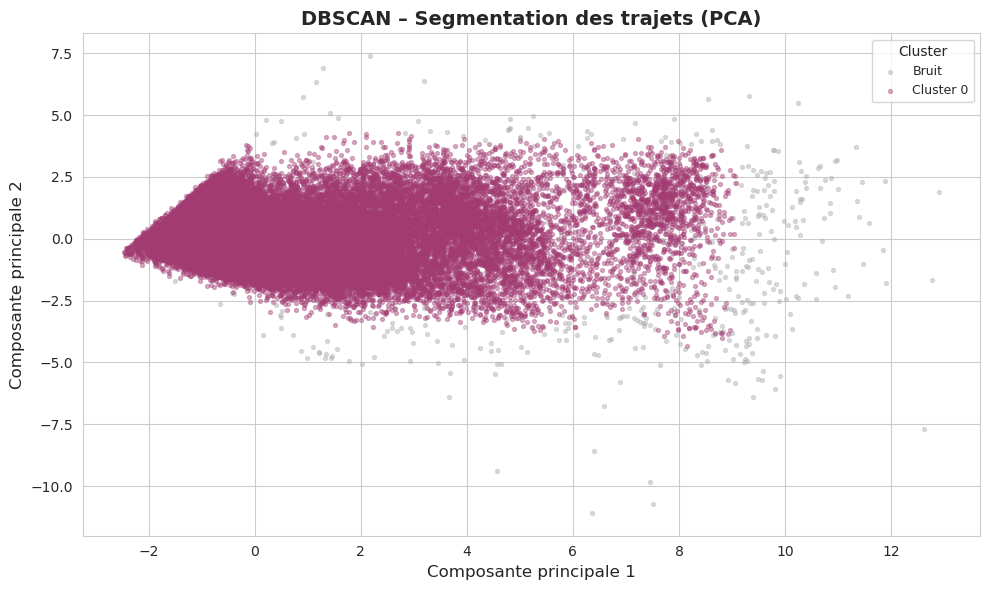

In [29]:
from sklearn.cluster import DBSCAN

# Entraînement DBSCAN sur les mêmes données standardisées que K-Means
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_scaled)

# Résultats
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_bruit = (labels_dbscan == -1).sum()

print(f"Nombre de clusters trouvés : {n_clusters}")
print(f"Points identifiés comme bruit : {n_bruit} ({n_bruit/len(labels_dbscan)*100:.1f}%)")

# Visualisation PCA des clusters DBSCAN
df_dbscan = pd.DataFrame(coords, columns=["PC1", "PC2"])
df_dbscan["cluster"] = labels_dbscan

plt.figure(figsize=(10, 6))
couleurs_db = {-1: "#AAAAAA"}  # gris pour le bruit
palette_db = ["#2E86AB", "#A23B72", "#F18F01", "#2DC653",
              "#E63946", "#6A0572", "#FF6B35", "#1B2A4A"]
for idx, cluster_id in enumerate(sorted(set(labels_dbscan))):
    mask = df_dbscan["cluster"] == cluster_id
    label = "Bruit" if cluster_id == -1 else f"Cluster {cluster_id}"
    couleur = "#AAAAAA" if cluster_id == -1 else palette_db[idx % len(palette_db)]
    plt.scatter(df_dbscan.loc[mask, "PC1"], df_dbscan.loc[mask, "PC2"],
                c=couleur, label=label, alpha=0.4, s=8)

plt.title("DBSCAN – Segmentation des trajets (PCA)", fontsize=14, fontweight="bold")
plt.xlabel("Composante principale 1", fontsize=12)
plt.ylabel("Composante principale 2", fontsize=12)
plt.legend(title="Cluster", fontsize=9)
plt.tight_layout()
plt.show()

## Analyse : DBSCAN vs K-Means

**Ce que DBSCAN apporte en plus :**

- Il identifie automatiquement les **courses atypiques** (points gris = bruit) que K-Means aurait forcées dans un cluster existant.
- Il ne nécessite pas de spécifier le nombre de clusters à l'avance.

**Comparaison des deux approches :**

| Critère | K-Means | DBSCAN |
|---------|---------|--------|
| Nombre de clusters | Fixé à k=4 | Trouvé automatiquement |
| Forme des clusters | Sphérique | Quelconque |
| Gestion des anomalies | Aucune | Identifiées comme bruit |
| Interprétabilité | Facile | Plus complexe |

**Conclusion :** K-Means reste plus adapté à notre jeu de données car les 4 profils identifiés sont bien sphériques et interprétables. DBSCAN est utile pour détecter les courses aberrantes qui n'appartiennent à aucun profil type.

## Conclusion générale

Ce projet nous a permis de mener un pipeline complet de Data Science sur les données des taxis jaunes de New York City, des données brutes jusqu'aux modèles de Machine Learning.

### Exploration et nettoyage (EDA)
Le jeu de données contenait de nombreuses valeurs aberrantes (distances nulles, montants négatifs, coordonnées GPS hors NYC, RatecodeID invalides, vitesses impossibles). Un nettoyage rigoureux basé sur les percentiles et des filtres métier a permis de conserver **97 923 trajets valides** sur 99 999 initiaux.

### Feature Engineering
La création de variables dérivées (duree_course, vitesse_moyenne, est_weekend, encodage cyclique sin/cos) a enrichi l'information disponible pour les modèles. L'analyse d'importance a confirmé que la distance reste la variable dominante.

### Apprentissage supervisé
Trois modèles ont été testés en progression :
- **Régression Linéaire** (baseline) : RMSE = 2.90$, R² = 0.9393
- **Random Forest** : RMSE = 2.70$, R² = 0.9443
- **XGBoost** : RMSE = 2.54$, R² = 0.9480

XGBoost donne les meilleures performances grâce au boosting. Les trois modèles confirment que le prix d'un taxi est principalement déterminé par la distance et la durée — une relation naturellement quasi-linéaire.

### Apprentissage non supervisé
Le K-Means avec k=4 a été validé par deux méthodes complémentaires : la méthode du coude et le score de silhouette (pic local à k=4 = 0.5502). Il a identifié 4 profils cohérents avec la réalité de NYC :
- Court trajet nocturne (~10$)
- Navetteur du soir (~24$)
- Court trajet matinal (~11$)
- Trajet aéroport (~52$)

DBSCAN a complété l'analyse en identifiant les courses atypiques que K-Means aurait forcées dans un cluster.

### Limites et perspectives
- L'analyse se limite à un mois de données (février 2016)
- L'échantillon présente un biais vers les jours de semaine (est_weekend ≈ 1%).
- Des modèles plus avancés (réseaux de neurones) pourraient encore améliorer les performances.